In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
pd.set_option('display.max_columns', None)

In [2]:
df = gpd.read_parquet('data/processed/wards_full_gdf(with_spatial_temporal_gini).parquet')

In [3]:
features = [
    # Structural
    "population", "poverty_rate", "pop_density",
    "coverage_ratio", "pct_access", "subcounty_gini",
    # Functional
    "trips_per_1k_pop_per_hour", "service_rank_overall", "service_rank_by_hour"
]

df1 = df[features].copy()

In [4]:
df.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   gid                        255 non-null    int64   
 1   pop2009                    255 non-null    float64 
 2   county                     255 non-null    object  
 3   subcounty                  255 non-null    object  
 4   ward                       255 non-null    object  
 5   uid                        255 non-null    object  
 6   scuid                      255 non-null    object  
 7   cuid                       255 non-null    object  
 8   geometry                   255 non-null    geometry
 9   population                 255 non-null    float64 
 10  constituency               255 non-null    object  
 11  poverty_rate               255 non-null    float64 
 12  intersect_area             255 non-null    float64 
 13  ward_area                  

In [5]:
from sklearn.preprocessing import StandardScaler
X = df1.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [6]:
from sklearn.cluster import KMeans
import pandas as pd

k = 4  # start with 4 clusters, you can tune later
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df1["cluster"] = kmeans.fit_predict(X_scaled)

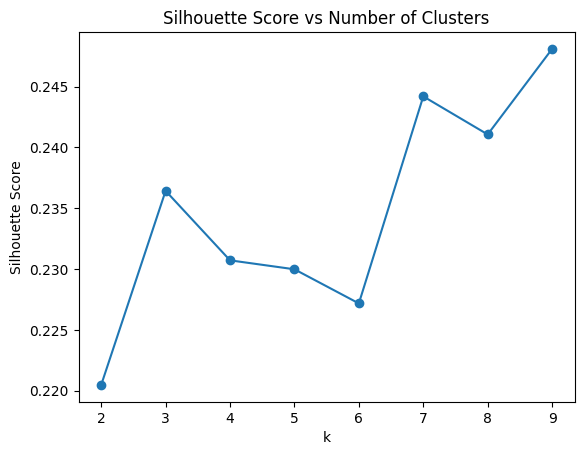

In [7]:
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

import matplotlib.pyplot as plt
plt.plot(range(2,10), scores, marker='o')
plt.title("Silhouette Score vs Number of Clusters")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.show()


In [8]:
df1

,population,poverty_rate,pop_density,coverage_ratio,pct_access,subcounty_gini,trips_per_1k_pop_per_hour,service_rank_overall,service_rank_by_hour,cluster
0,74177.992829,11.1,160022.77,0.883669,88.366913,0.076869,0.161773,235,79,2
1,74177.992829,11.1,160022.77,0.883669,88.366913,0.076869,0.053924,237,79,2
2,74177.992829,11.1,160022.77,0.883669,88.366913,0.076869,0.161773,235,79,2
3,92557.211478,13.8,23645.36,0.676181,67.618095,0.268249,5.70458,123,50,3
4,92557.211478,13.8,23645.36,0.676181,67.618095,0.268249,1.901527,192,50,1
...,...,...,...,...,...,...,...,...,...,...
250,74514.220482,14.5,111517.37,0.999643,99.964329,0.046200,2.254603,186,44,2
251,74514.220482,14.5,111517.37,0.999643,99.964329,0.046200,6.76381,103,44,2
252,154593.609337,17.9,7256.19,0.586949,58.694894,0.169643,10.711956,82,37,3
253,154593.609337,17.9,7256.19,0.586949,58.694894,0.169643,3.570652,161,37,3


In [9]:
df["cluster"] = df1["cluster"].values


<Axes: >

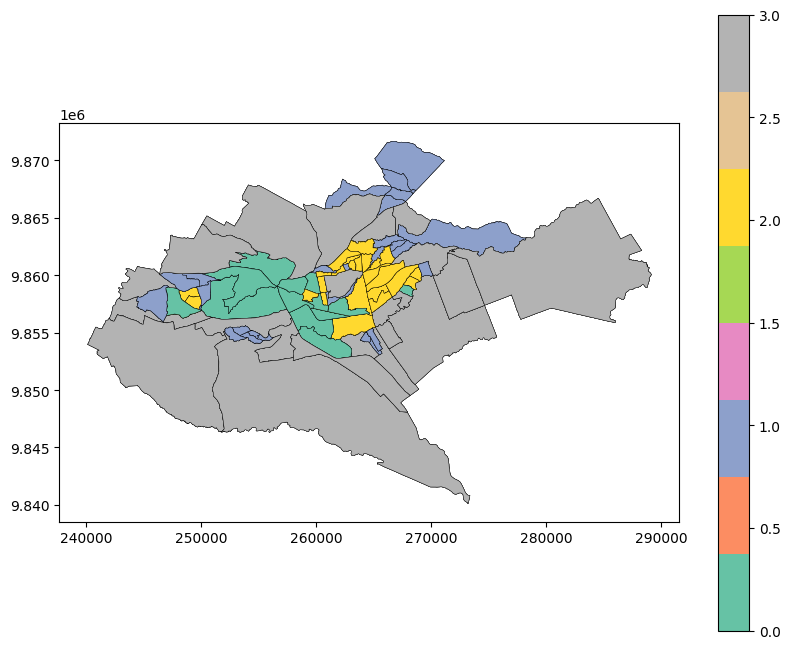

In [10]:
df.plot(
    column="cluster",
    cmap="Set2",
    legend=True,
    figsize=(10, 8),
    edgecolor="black",
    linewidth=0.3
)


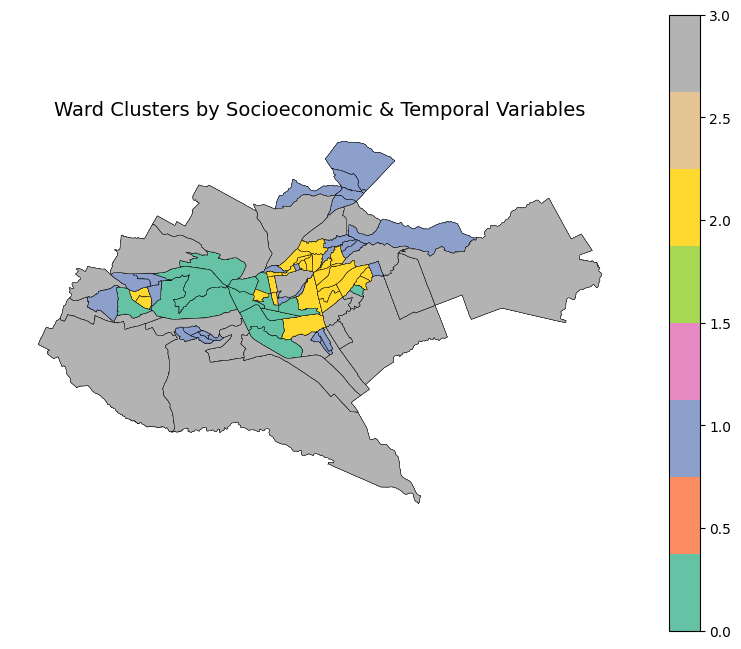

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
df.plot(column="cluster", cmap="Set2", legend=True, edgecolor="black", linewidth=0.3, ax=ax)
plt.title("Ward Clusters by Socioeconomic & Temporal Variables", fontsize=14)
plt.axis("off")
plt.savefig("data/training_output/ward_cluster_temporal.png", dpi=300, bbox_inches="tight")
plt.show()